<a href="https://colab.research.google.com/github/kaonashithank1022/data-analysis-basic-kadai/blob/main/text/15%E7%AB%A0_%E6%99%82%E7%B3%BB%E5%88%97%E5%88%86%E6%9E%90%E3%81%AE%E6%89%8B%E6%B3%95%E3%82%92%E5%AD%A6%E3%81%BC%E3%81%86_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


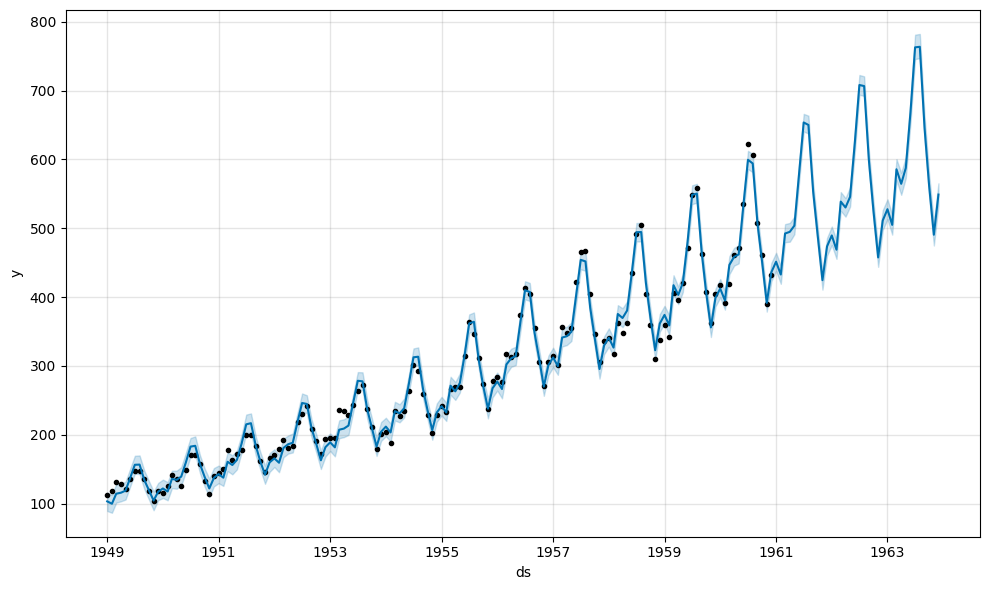

In [11]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_air_passengers.csv')

#Prophetクラスをインポートしてインスタンス化
#引数にseasonality_mode='multiplicative'を設定することによって、周期性変動が徐々に拡大する予測モデルを構築
#★前章から改善したところ★
from prophet import Prophet
model = Prophet(seasonality_mode='multiplicative')

#
#過去の時系列データであるdfを引数に指定して、fitメソッドを実行
model.fit(df)

#向こう3年の日付が入った空白のカレンダーを用意する
future = model.make_future_dataframe(periods=36, freq='MS')

#未来のカレンダーに予測結果を書き込む
forecast = model.predict(future)

#出力された予測値と、不確実性区間を確認
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

#グラフで可視化
fig_forecast = model.plot(forecast)

  0%|          | 0/4 [00:00<?, ?it/s]

[(0.0, 5000.0)]

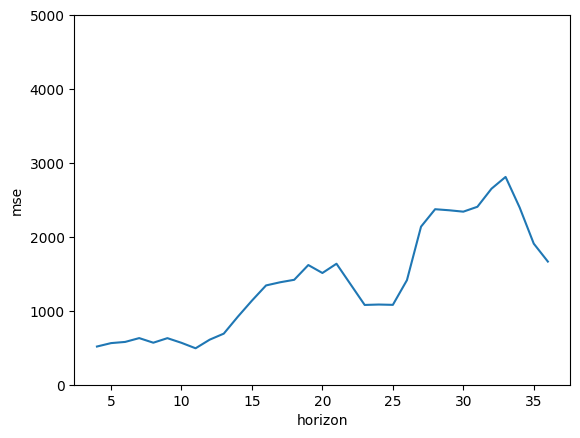

In [14]:
#周期性が徐々に拡大する予測モデルを利用する

#cutoffsとして、4つの日付を持つデータを作成
cutoffs = pd.to_datetime(['1954-12-01', '1955-12-01', '1956-12-01', '1957-12-01'])

#cross_validation関数をインポートし、実行してテストパターンを作成
from prophet.diagnostics import cross_validation
#引数には、cutoffsとhorizonを指定
df_cv = cross_validation(model, horizon = '1096 days', cutoffs=cutoffs)



#performance_metrics関数をインポートし、引数にdf_cvとmonthly=Trueを指定して実行
#df_cvをもとに各評価指標を算出
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv, monthly=True)
df_p.head()

#実際の値と予測値の平均二乗誤差であるmseの推移を可視化
#lineplot:データを「折れ線グラフ」にして表示するための命令
#setメソッドのylimパラメータに、y軸の下限と上限を指定
sns.lineplot(x='horizon', y='mse', data=df_p).set(ylim=(0, 5000))

<Axes: xlabel='horizon', ylabel='coverage'>

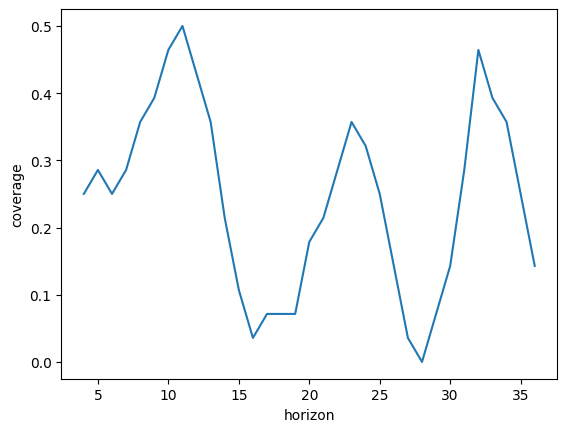

In [19]:
#不確実性区間に予測値が含まれている割合である、coverageの推移を確認
sns.lineplot(x='horizon', y='coverage', data=df_p)
